# pyOMA-Monitoring — Capabilities Demonstration

## Project Description

This notebook demonstrates the full SHM data pipeline for a 200 m tall **freestanding telecommunication mast**.  The
structure has been continuously monitored since 2015 as part of research at the Bauhaus-Universität Weimar.  The monitoring system collects:

| Sensor type | Positions | Channel names |
|---|---|---|
| Uniaxial accelerometers (PCB) | +107.5 m, +126.9 m, +141.9 m, +163.9 m, +188 m | `Accel_01` … `Accel_08`, `Accel_01_top` … `Accel_04_top` |
| Ultrasonic anemometers (Thies) | +108 m, +188 m | `Wg`, `Wr`, `Wg_top`, `Wr_top` |
| Pt100 thermometers | +108.9 m (4 × outside, 1 × inside) | `Pt100_01` … `Pt100_05` |
| FBG strain-gauge rosettes (Illumisense) | 4 sections near the lower anchorage | `A_z`, `A_t`, `A_zt`, `B_*`, `C_*`, `D_*`, plus temperature channels |

The **two independent data-acquisition systems** (Gantner Q.Station for acceleration /
wind / temperature, and a Windows PC for FBG strain data) historically used different
time bases, which required careful synchronisation before joint analysis.

---

### Pipeline overview

```
Raw binary files (.dat / .csv / .bin)
        │
        ▼  ReadBinary / udbf2ascii (low-level readers)
   read_file()
        │
        ▼  get_file_info() / create_file_info()
   file_info_<qty>.nc   ← one NetCDF per quantity, index of all raw files
        │
        ▼  get_stats() / create_stats()  →  get_slice_corrected()
   stats_<qty>.nc       ← signal statistics in equal-length time blocks
        │
        ▼  get_modal_results() / create_modal_results()  →  VarSSIRef
   modal_<qty>.nc       ← identified modal parameters per time block
        │
        ▼  post_processing.py
   Matplotlib figures   ← daily overview / frequency scatter / waterfall
```

Each stage is illustrated in detail in the sections below.

## Setup — imports and project configuration

In [1]:
import sys, os

# If this notebook is placed inside the package directory the following line is
# not needed.  If you moved it elsewhere, adjust the path to the package root.
PACKAGE_DIR = os.path.dirname(os.path.abspath('__file__'))
if PACKAGE_DIR not in sys.path:
    sys.path.insert(0, PACKAGE_DIR)

import logging
logging.basicConfig(level=logging.WARNING)   # quiet for the demo; set INFO to see pipeline progress

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib
import matplotlib.pyplot as plt
import pytz, datetime

matplotlib.rcParams['figure.dpi'] = 110
%matplotlib inline

# project modules — import site_tower first: it registers and activates the tower site
import site_tower                      # noqa: F401
import monitoring
from monitoring import (
    get_file_list, read_file,
    get_file_info, create_file_info,
    get_synchronized_time, close_to_utc_transition, round_dt,
    get_slice, get_slice_corrected, get_slice_preprocessed,
    describe_stats,
    get_stats,
    get_modal_results,
)

site = monitoring.get_active_site()   # Site dataclass carrying all tower configuration

print('site.file_root_path  :', site.file_root_path)
print('site.db_root_path    :', site.db_root_path)
print('Available quantities :', list(site.origins.keys()))

site.file_root_path  : /home/womo1998/Projects/grkgeyer/
site.db_root_path    : /home/womo1998/Projects/grkgeyer/analysis/result_db/
Available quantities : ['accel', 'wind', 'temp', 'strain_rosettes', 'strain_bolts']


---
## 1 — Reading a single measurement file

The lowest level of the pipeline is `read_file()`.  It accepts any of the supported
raw formats:

| Extension | Origin | Reader |
|---|---|---|
| `.dat` | Gantner Q.Station (UDBF binary) | `udbf2ascii.read_bin()` |
| `.csv` | Gantner Q.Station (UDBF ASCII) | `udbf2ascii.read_csv()` |
| `.bin` | Illumisense FBG interrogator | `ReadBinary.read_bin()` |
| `_` (prefix) | Illumisense split-channel `.txt` | `ReadBinary.read_strain_txt()` |
| Any of the above + `.bz2` | bzip2-compressed version | transparent decompression |

A cached `.npz` version is written alongside the original on first read, so
subsequent calls are ~2000× faster.

`read_file()` returns a 7-tuple:
```python
(file_time, file_size, headers, units, start_time, sample_rate, measurement)
```

* `file_time` — filesystem modification time (timezone-aware)
* `file_size` — bytes
* `headers`   — list of channel names
* `units`     — list of unit strings
* `start_time` — recording start from the device's internal clock (timezone-aware)
* `sample_rate` — samples per second (float)
* `measurement` — `np.ndarray` of shape `(n_samples, n_channels)`, dtype float64

In [2]:
# Pick the first acceleration file that is present on disk
accel_dir = os.path.join(site.file_root_path, site.subpaths['accel'])
all_dat = sorted([
    f for f in os.listdir(accel_dir)
    if f.startswith('Accel_continuously') and f.endswith('.dat')
])
print(f'Found {len(all_dat)} .dat files.  First: {all_dat[0]}')

example_file = os.path.join(accel_dir, all_dat[0])

# Read the file
result = read_file(example_file)

file_time, file_size, headers, units, start_time, sample_rate, measurement = result

print(f'\nFile size      : {file_size / 1e6:.2f} MB')
print(f'File mod time  : {file_time}')
print(f'Device start   : {start_time}')
print(f'Sample rate    : {sample_rate} Hz')
print(f'Signal shape   : {measurement.shape}  →  {measurement.shape[0]/sample_rate/3600:.2f} h')
print(f'Channels       : {headers}')
print(f'Units          : {units}')

INFO:monitoring:Reading File: Accel_continuously__0_2026-06-21_18-00-00_000000.dat


Found 25 .dat files.  First: Accel_continuously__0_2026-06-21_18-00-00_000000.dat

File size      : 14.40 MB
File mod time  : 2026-06-22 22:12:01.471926+02:00
Device start   : 2026-06-21 18:00:00+00:00
Sample rate    : 100.0 Hz
Signal shape   : (360000, 9)  →  1.00 h
Channels       : ['Time', 'Accel_03', 'Accel_04', 'Accel_05', 'Accel_06', 'Accel_07', 'Accel_08', 'Accel_01', 'Accel_02']
Units          : ['s', 'm/s^2', 'm/s^2', 'm/s^2', 'm/s^2', 'm/s^2', 'm/s^2', 'm/s^2', 'm/s^2']


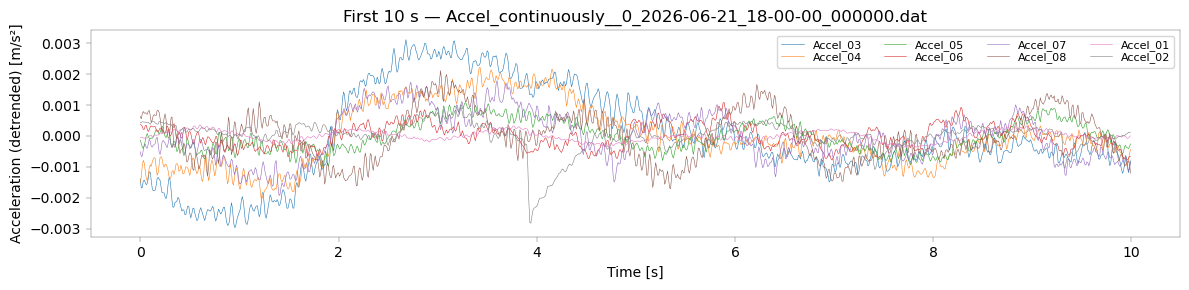

In [3]:
# Quick time-series plot of the first 10 seconds
secs = 10
n = int(secs * sample_rate)
t = np.arange(n) / sample_rate          # time axis in seconds

accel_cols = [i for i, h in enumerate(headers) if 'Accel' in h]

fig, ax = plt.subplots(figsize=(12, 3))
for col in accel_cols:
    ax.plot(t, measurement[:n, col] - measurement[:n, col].mean(),
            lw=0.4, label=headers[col])
ax.set_xlabel('Time [s]')
ax.set_ylabel('Acceleration (detrended) [m/s²]')
ax.set_title(f'First {secs} s — {os.path.basename(example_file)}')
ax.legend(ncol=4, fontsize=8)
plt.tight_layout()
plt.show()

---
## 2 — The file_info database

`file_info_<quantity>.nc` is the **master index** of all raw files for a given quantity.
It is built once by `create_file_info()` and updated incrementally by
`get_file_info(create_new=True, skip_existing=True)`. The file is an xarray multi-dimensional dataset.

### Schema

```
Coordinates
    time       (UTC, naive)  — synchronised start time of each file
    channels   (str)         — common channel names across all files

Data variables — file metadata
    file_name  (time,)           — original filename (without path)
    file_size  (time,)           — bytes on disk
    file_time  (time,)           — POSIX timestamp of filesystem mtime (float64)
    start_time (time,)           — POSIX timestamp from device clock  (float64)
    sample_rate(time,)           — Hz
    duration   (time,)           — recording duration in µs (float64, attrs: dtype=timedelta64[s])
    length     (time,)           — number of samples
    num_channels(time,)          — channel count

Data variables — per-file signal statistics
    mean, min, max, var, skewness, kurtosis
    q05, q50, q95, rms           — (time, channels)
    error                        — (time, channels)  bool-like; True if channel is suspect
```

The signal statistics stored here are computed from the **full raw file**, not from
analysis blocks, so they give a quick overview of the sensor health over time.

The `gap_length` variable is **not** stored in the file but is re-derived on every load
by `compute_gap_lengths()`, because it depends on the complete chronological order of
all files — something that changes as new files arrive.

In [4]:
# Load the existing file_info database for accelerometers
fi = get_file_info('accel', create_new=False)

print('Dataset dimensions :', dict(fi.sizes))
print('Variables          :', list(fi.data_vars))
print('Channels           :', list(fi.channels.values))
print()

# The time coordinate is UTC-naive; convert for display
times_utc = pd.DatetimeIndex(fi.time.values, tz='UTC')
print(f'Time range : {times_utc[0]}  →  {times_utc[-1]}')
print(f'Number of files: {len(fi.time)}')

INFO:monitoring:Getting file info for accel


Dataset dimensions : {'time': 25, 'channels': 9}
Variables          : ['file_name', 'file_size', 'file_time', 'start_time', 'num_channels', 'units', 'sample_rate', 'duration', 'length', 'mean', 'min', 'max', 'var', 'skewness', 'kurtosis', 'q05', 'q50', 'q95', 'rms', 'error', 'gap_length']
Channels           : [np.str_('Time'), np.str_('Accel_03'), np.str_('Accel_04'), np.str_('Accel_05'), np.str_('Accel_06'), np.str_('Accel_07'), np.str_('Accel_08'), np.str_('Accel_01'), np.str_('Accel_02')]

Time range : 2026-06-21 18:00:00+00:00  →  2026-06-22 18:00:00+00:00
Number of files: 25


In [5]:
# Inspect one entry
entry = fi.isel(time=0)
print('file_name  :', entry['file_name'].values.item())
print('sample_rate:', entry['sample_rate'].values.item(), 'Hz')
print('length     :', entry['length'].values.item(), 'samples')

# start_time and file_time are stored as POSIX timestamps (float64)
# to recover them as tz-aware datetimes:
st_posix = entry['start_time'].values.item()       # seconds since Unix epoch (UTC)
st_dt = pd.Timestamp(st_posix, unit='s', tz='UTC')
print('start_time :', st_dt)

# duration is stored in seconds as float64
dur_us = entry['duration'].values.item()
print('duration   :', pd.Timedelta(dur_us, unit='s'))

file_name  : Accel_continuously__0_2026-06-21_18-00-00_000000.dat
sample_rate: 100.0 Hz
length     : 360000.0 samples
start_time : 2026-06-21 18:00:00+00:00
duration   : 0 days 01:00:00


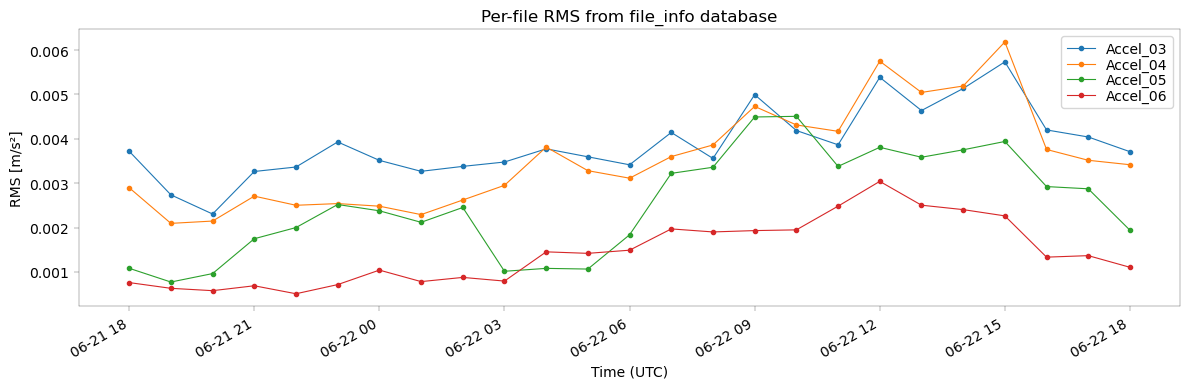

In [6]:
# Plot per-file RMS for a subset of channels over the available data range
accel_channels = [c for c in fi.channels.values if 'Accel' in str(c)]

fig, ax = plt.subplots(figsize=(12, 4))
for ch in accel_channels[:4]:
    rms_data = fi['rms'].sel(channels=ch)
    ax.plot(pd.DatetimeIndex(fi.time.values, tz='UTC'),
            rms_data.values, marker='.', lw=0.8, label=ch)
ax.set_ylabel('RMS [m/s²]')
ax.set_xlabel('Time (UTC)')
ax.set_title('Per-file RMS from file_info database')
ax.legend()
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [7]:
# Gap lengths between consecutive files (re-derived each time)
if 'gap_length' in fi:
    gap_s = fi['gap_length'] / fi['sample_rate']   # convert samples → seconds
    gap_s_vals = gap_s.values[:-1]                  # last entry is always NaN
    has_gap = gap_s_vals[np.isfinite(gap_s_vals)] > 1.0
    print(f'Files with gaps > 1 s: {has_gap.sum()} / {len(gap_s_vals)}')
    print(f'Largest gap: {np.nanmax(gap_s_vals):.1f} s')
else:
    print('gap_length not in dataset (expected — it is computed on load, not stored)')

Files with gaps > 1 s: 1 / 24
Largest gap: 2.0 s


---
## 2a — Timestamp synchronisation: local time → UTC

Over the 10+ year operating period, **two independent data-acquisition systems** ran
simultaneously and handled time very differently:

| System | Sensor types | Time base | Daylight saving |
|---|---|---|---|
| Gantner Q.Station | acceleration, wind, temperature | Own internal clock, effectively UTC-like — never explicitly configured, drifted slowly | Not applied |
| Windows 7 PC (Illumisense) | FBG strain gauges | PC clock set to `Europe/Berlin` | Applied automatically until 2019-04-30 |

The resulting **timeline of known time-setting events** is:

| Date | Event |
|---|---|
| 2016-12-15 | Strain (FBG) recordings started |
| 2017-10-29 | Last DST clock change before NTP was set up |
| 2018-01-25 | NTP activated on PC; strain compression script changed |
| 2018-05-24 | Q.Station compression script changed → file timestamps lost for new files |
| 2019-04-30 | PC set to UTC, DST disabled |

The synchronisation strategy implemented in `get_synchronized_time()` is:

```
before 2016-12-15  → no synchronisation needed (only Q.Station running)
2016-12-15 to 2018-01-25 → use file_time − duration   (NTP not yet set; file mtime is best reference)
2018-01-25 to 2019-04-30 → use start_time             (PC 2 h ahead of controller; already corrected in ReadBinary.localize)
after 2019-04-30   → use start_time                   (both systems UTC)
```

After synchronisation, **all times are converted to UTC and stored without timezone
information** (UTC-naive) as the `time` coordinate in every NetCDF database.  This
avoids the ambiguous hour at the autumn DST transition.

The function `close_to_utc_transition()` flags files recorded within ±3 h of a
Berlin DST boundary and **skips** them from the analysis to prevent mis-attribution.

In [8]:
# Demonstrate the timeline of DST transitions used for screening
berlin = pytz.timezone('Europe/Berlin')
dst_transitions = berlin._utc_transition_times[100:108]   # transitions ~2015–2022

print('DST transition times used for exclusion windows (UTC):')
for t in dst_transitions:
    local = berlin.localize(t.replace(tzinfo=None)).strftime('%Y-%m-%d %H:%M %Z')
    print(f'  {t}  →  {local}')

DST transition times used for exclusion windows (UTC):
  2016-03-27 01:00:00  →  2016-03-27 01:00 CET
  2016-10-30 01:00:00  →  2016-10-30 01:00 CEST
  2017-03-26 01:00:00  →  2017-03-26 01:00 CET
  2017-10-29 01:00:00  →  2017-10-29 01:00 CEST
  2018-03-25 01:00:00  →  2018-03-25 01:00 CET
  2018-10-28 01:00:00  →  2018-10-28 01:00 CEST
  2019-03-31 01:00:00  →  2019-03-31 01:00 CET
  2019-10-27 01:00:00  →  2019-10-27 01:00 CEST


In [9]:
# Show get_synchronized_time() logic for the three periods
import datetime

berlin = pytz.timezone('Europe/Berlin')

# Illustrative (synthetic) timestamps — the function is deterministic
test_cases = [
    ('Pre-NTC (before 2016-12-15)', datetime.datetime(2016, 6, 1, 10, 0, tzinfo=berlin)),
    ('File-time era (2016-12 to 2018-01)', datetime.datetime(2017, 6, 1, 10, 0, tzinfo=berlin)),
    ('Post-NTP, pre-UTC (2018-01 to 2019-04)', datetime.datetime(2018, 8, 1, 10, 0, tzinfo=berlin)),
    ('Post-UTC (after 2019-04-30)', datetime.datetime(2020, 3, 15, 10, 0, tzinfo=berlin)),
]

duration = datetime.timedelta(hours=3)
for label, start in test_cases:
    file_t = start + duration  # file written 3 h after start
    sync = get_synchronized_time(start, file_t, duration)
    print(f'{label}')
    print(f'  device start_time  : {start}')
    print(f'  file_time          : {file_t}')
    print(f'  → synchronised time: {sync}')
    print()

Pre-NTC (before 2016-12-15)
  device start_time  : 2016-06-01 10:00:00+00:53
  file_time          : 2016-06-01 13:00:00+00:53
  → synchronised time: 2016-06-01 10:00:00+00:53

File-time era (2016-12 to 2018-01)
  device start_time  : 2017-06-01 10:00:00+00:53
  file_time          : 2017-06-01 13:00:00+00:53
  → synchronised time: 2017-06-01 10:00:00+00:53

Post-NTP, pre-UTC (2018-01 to 2019-04)
  device start_time  : 2018-08-01 10:00:00+00:53
  file_time          : 2018-08-01 13:00:00+00:53
  → synchronised time: 2018-08-01 10:00:00+00:53

Post-UTC (after 2019-04-30)
  device start_time  : 2020-03-15 10:00:00+00:53
  file_time          : 2020-03-15 13:00:00+00:53
  → synchronised time: 2020-03-15 10:00:00+00:53



In [10]:
# Demonstrate UTC storage convention
# create_stats() iterates over Berlin-local timestamps and converts to UTC for storage

# Example: a 120-minute block starting at 02:00 Berlin time on the morning
# when clocks spring forward (last Sunday of March)
# The 02:00–04:00 slot does not exist in local time → tz_localize returns NaT

spring_forward_date = '2024-03-31 02:00'   # does not exist in Europe/Berlin
ts_ambiguous = pd.Timestamp(spring_forward_date)

try:
    ts_aware = ts_ambiguous.tz_localize('Europe/Berlin', nonexistent='raise')
    print('Localised to:', ts_aware)
except Exception as e:
    print(f'NonExistentTimeError: {e}')
    print("→ create_stats() calls tz_localize(nonexistent='NaT') and skips this slot.")

print()

# A normal summer slot
summer_slot = pd.Timestamp('2024-07-15 02:00')
summer_utc = summer_slot.tz_localize('Europe/Berlin').tz_convert('UTC').tz_localize(None)
print(f'Summer 02:00 Berlin → {summer_utc} UTC (stored as-is in NetCDF)')

# A winter slot — 2 h offset instead of 1
winter_slot = pd.Timestamp('2024-01-15 02:00')
winter_utc = winter_slot.tz_localize('Europe/Berlin').tz_convert('UTC').tz_localize(None)
print(f'Winter 02:00 Berlin → {winter_utc} UTC')

NonExistentTimeError: 2024-03-31 02:00:00 is a nonexistent time due to daylight savings time. Try using the 'nonexistent' argument.
→ create_stats() calls tz_localize(nonexistent='NaT') and skips this slot.

Summer 02:00 Berlin → 2024-07-15 00:00:00 UTC (stored as-is in NetCDF)
Winter 02:00 Berlin → 2024-01-15 01:00:00 UTC


The consequence is that **120-minute UTC timestamps alternate between even and odd hour
values** depending on the season, because the DST offset alternates between UTC+1 and
UTC+2.  This is expected and intentional — it is the correct UTC representation of
equally-spaced Berlin-local analysis blocks.

---
## 3 — Statistical analysis and the stats database

`stats_<quantity>.nc` holds signal statistics computed on **fixed-length, non-overlapping
time blocks** (10 / 30 / 60 / 120 minutes).  Each block is produced by
`get_slice_corrected()` → `describe_stats()`.

### Schema

```
Coordinates
    time       (UTC-naive)   — start of the analysis block
    channels   (str)         — channel names in this quantity

Signal metadata
    num_channels  (time,)
    sample_rate   (time,)
    length        (time,)      — samples in this block
    error         (time, channels) — True if channel was flagged suspect

Per-channel statistics
    mean, min, max, var, skewness, kurtosis,
    q05, q50, q95, rms           — (time, channels)
```

### Error flagging in `describe_stats()`

A channel is marked `error=True` when any of these conditions is triggered:
- `min == max`  (stuck sensor / flat line)
- value exceeds the physical plausibility range defined in `site.ranges` (populated from `config.py` by `site_tower.py`)
- kurtosis > 5 or kurtosis < -2  (for vibration quantities — transient or clipping)
- all samples are NaN

In [11]:
# Load the 120-minute statistics database
duration = pd.Timedelta(minutes=120)
stats = get_stats('accel', duration)

print('Dimensions :', dict(stats.sizes))
print('Channels   :', list(stats.channels.values))
print('Time range :', pd.to_datetime(stats.time.values[[0, -1]]))
print('Variables  :', [v for v in stats.data_vars])

INFO:monitoring:Getting statistics for accel


Dimensions : {'time': 15, 'channels': 8}
Channels   : [np.str_('Accel_03'), np.str_('Accel_04'), np.str_('Accel_05'), np.str_('Accel_06'), np.str_('Accel_07'), np.str_('Accel_08'), np.str_('Accel_01'), np.str_('Accel_02')]
Time range : DatetimeIndex(['2026-06-21 12:00:00', '2026-06-22 16:00:00'], dtype='datetime64[ns]', freq=None)
Variables  : ['num_channels', 'sample_rate', 'length', 'mean', 'min', 'max', 'var', 'skewness', 'kurtosis', 'q05', 'q50', 'q95', 'rms', 'error']


In [12]:
# Show statistics for the first non-empty block
valid_mask = ~stats['rms'].isnull().all(dim='channels')
first_valid = stats.isel(time=valid_mask).isel(time=0)

block_time = pd.Timestamp(first_valid.time.values, tz='Europe/Berlin')
print(f'Block start (Berlin): {block_time}')
print(f'Block length: {first_valid["length"].values.item()} samples '
      f'= {first_valid["length"].values.item() / first_valid["sample_rate"].values.item() / 60:.0f} min')
print()

import pandas as pd
summary = pd.DataFrame({
    'mean':     first_valid['mean'].values,
    'rms':      first_valid['rms'].values,
    'kurtosis': first_valid['kurtosis'].values,
    'error':    first_valid['error'].values,
}, index=list(stats.channels.values))
print(summary.to_string(float_format='{:.4g}'.format))

Block start (Berlin): 2026-06-21 18:00:00+02:00
Block length: 720000.0 samples = 120 min

              mean       rms  kurtosis  error
Accel_03   -0.1378  0.003974   -0.5733      0
Accel_04   -0.1726  0.002843   -0.4965      0
Accel_05  -0.03376 0.0009722    0.6114      0
Accel_06  -0.08079 0.0009959  -0.04838      0
Accel_07  -0.04208   0.00131    0.6389      0
Accel_08   -0.0245  0.001167     3.677      0
Accel_01 -0.005275 0.0002102     3.949      0
Accel_02 -0.009103 0.0004772     11.59      1


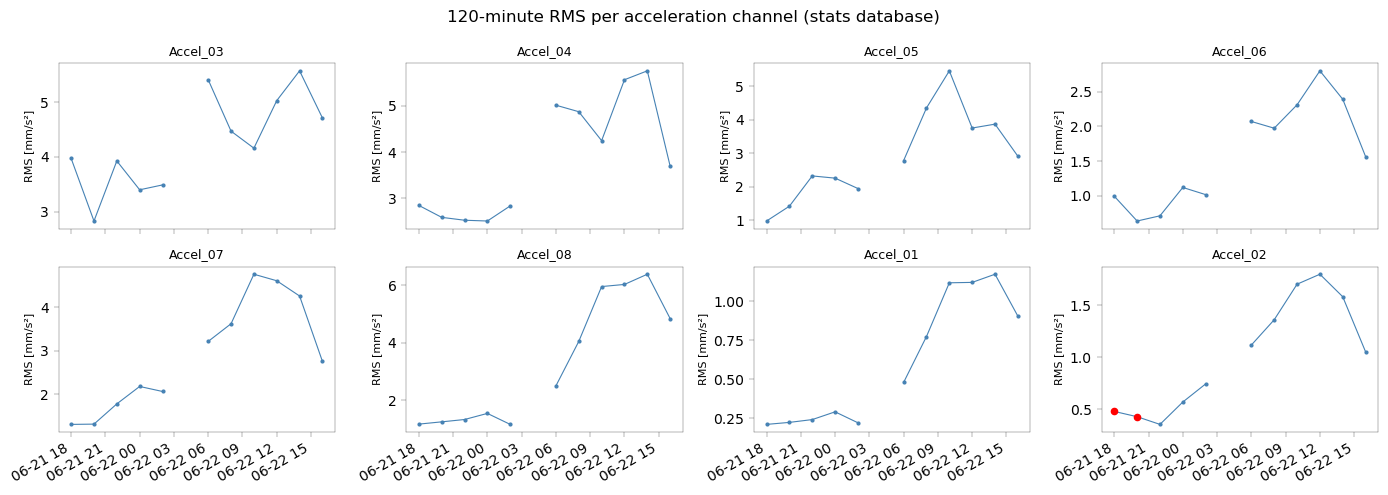

In [13]:
# Visualise RMS time series for each acceleration channel
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 5), sharex=True, sharey=False)
axes = axes.flatten()

times_plot = pd.DatetimeIndex(stats.time.values, tz='UTC')

for i, ch in enumerate(stats.channels.values):
    rms_vals = stats['rms'].sel(channels=ch).values * 1e3   # convert to mm/s²
    err_mask = stats['error'].sel(channels=ch).values.astype(bool)

    axes[i].plot(times_plot, rms_vals, marker='.', ms=4, lw=0.8, color='steelblue')
    axes[i].scatter(times_plot[err_mask], rms_vals[err_mask], color='red', zorder=5, s=20, label='error')
    axes[i].set_title(str(ch), fontsize=9)
    axes[i].set_ylabel('RMS [mm/s²]', fontsize=8)

fig.suptitle('120-minute RMS per acceleration channel (stats database)')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [14]:
# Demonstrate describe_stats() on a synthetic signal for pedagogical clarity
import scipy.stats

rng = np.random.default_rng(42)
n_samples, n_ch = 12000, 3
synth = rng.standard_normal((n_samples, n_ch)) * np.array([0.5, 0.1, 2.0])
synth_headers = ['ch_normal', 'ch_quiet', 'ch_loud']

stats_dict = describe_stats(synth, synth_headers, quantity='accel')

df_synth = pd.DataFrame(stats_dict, index=synth_headers)
print('describe_stats() output:')
print(df_synth[['mean', 'rms', 'min', 'max', 'skewness', 'kurtosis', 'error']].to_string(
    float_format='{:.3f}'.format))
print()
print('Note: kurtosis for a Gaussian distribution is 0 (excess kurtosis convention).')
print('error flags kick in at |kurtosis| > 5 or 2 for vibration quantities.')

describe_stats() output:
            mean   rms    min   max  skewness  kurtosis  error
ch_normal  0.008 0.504 -2.129 2.076     0.015    -0.002  0.000
ch_quiet   0.001 0.100 -0.365 0.372     0.031     0.034  0.000
ch_loud   -0.011 2.006 -8.778 8.176    -0.018    -0.051  0.000

Note: kurtosis for a Gaussian distribution is 0 (excess kurtosis convention).
error flags kick in at |kurtosis| > 5 or 2 for vibration quantities.


INFO:monitoring:Getting statistics for wind
INFO:monitoring:Getting statistics for temp


stats_wind channels : [np.str_('Wg'), np.str_('Wr'), np.str_('Wx'), np.str_('Wy')]
stats_temp channels : [np.str_('Pt100_05'), np.str_('Pt100_01'), np.str_('Pt100_02'), np.str_('Pt100_03'), np.str_('Pt100_04')]


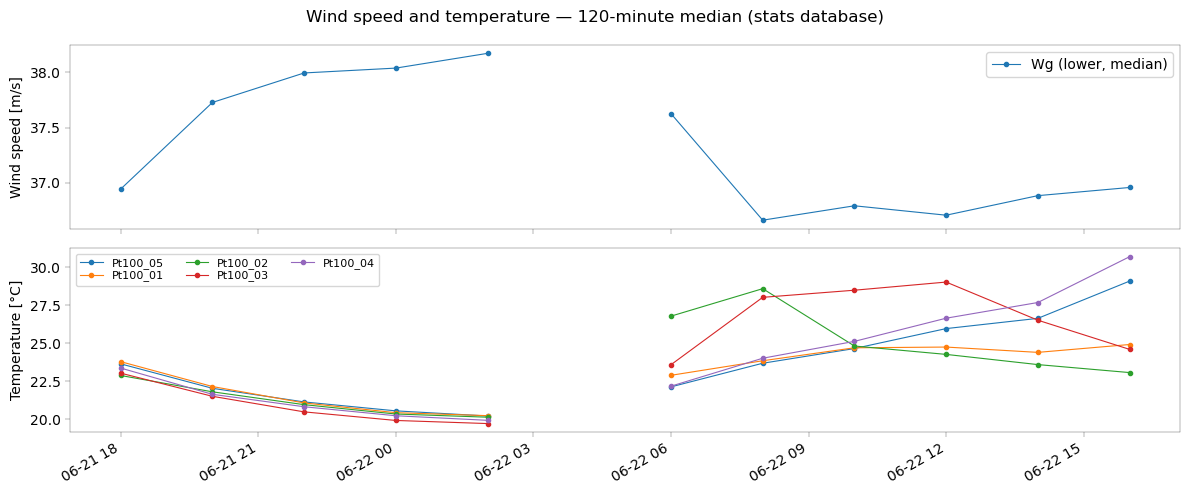

In [15]:
# Also load wind and temperature statistics to show they share the same schema
stats_wind = get_stats('wind', duration)
stats_temp = get_stats('temp', duration)

print('stats_wind channels :', list(stats_wind.channels.values))
print('stats_temp channels :', list(stats_temp.channels.values))

# Plot wind speed median (q50)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

t_wind = pd.DatetimeIndex(stats_wind.time.values, tz='UTC')
if 'Wg' in stats_wind.channels.values:
    ax1.plot(t_wind, stats_wind['q50'].sel(channels='Wg').values,
             marker='.', lw=0.8, label='Wg (lower, median)')
if 'Wg_top' in stats_wind.channels.values:
    ax1.plot(t_wind, stats_wind['q50'].sel(channels='Wg_top').values,
             marker='.', lw=0.8, label='Wg_top (upper, median)')
ax1.set_ylabel('Wind speed [m/s]')
ax1.legend()

t_temp = pd.DatetimeIndex(stats_temp.time.values, tz='UTC')
for ch in stats_temp.channels.values:
    ax2.plot(t_temp, stats_temp['q50'].sel(channels=ch).values,
             marker='.', lw=0.8, label=str(ch))
ax2.set_ylabel('Temperature [°C]')
ax2.legend(ncol=3, fontsize=8)

fig.suptitle('Wind speed and temperature — 120-minute median (stats database)')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

---
## 4 — Modal analysis

Operational Modal Analysis (OMA) is performed on each analysis block by
`create_modal_results()`, which calls `get_slice_preprocessed()` followed by
`modal_analysis_single()`.

### Pre-processing (`get_slice_preprocessed`)

1. `get_slice_corrected()` — stitches raw files together and corrects timestamps
2. 4th-order Butterworth band-pass filter: 0.1 – 5 Hz
3. Decimation by `round(sample_rate / 10)` → target 10 Hz
4. For strain data: select only rosette channels `A_z, A_t, A_zt, …`

### OMA method: Variance-based SSI with Reference channels (VarSSIRef)

The pipeline calls `pyOMA`'s `VarSSIRef`, then runs automated clustering and
selection via `StabilCluster`:

```
PreProcessSignals  →  VarSSIRef  →  StabilCluster
   (prep_data)         (modal_data)   (stabil_calc)
       ↓                   ↓               ↓
  sv_psd (singular    state-space    automatic_clearing
  value PSD)          matrices       automatic_classification
                                     automatic_selection
                                           ↓
                               return_results() → (n, f, std_f, d, std_d, MPC, …)
```

### Modal result database schema

```
Coordinates
    time      (UTC-naive)  — block start
    channels  (str)        — same channels as the stats database
    modes     (int)        — mode index (0-based, up to max identified modes)

OMA results
    num_modes        (time,)
    frequencies      (time, modes)  — natural frequencies [Hz]
    std_frequencies  (time, modes)  — uncertainty (natural frequencies standard deviation)
    damping          (time, modes)  — modal damping ratios [%]
    std_damping      (time, modes)  — uncertainty (damping ratios standard deviation)
    model_orders     (time, modes)  — SSI model order at selection
    MPC              (time, modes)  — Modal Phase Collinearity (1 = real mode)
    MPD              (time, modes)  — Mean Phase Deviation [°]
    modeshapes       (time, modes, channels)

SVD-PSD statistics (of singular value spectra)
    max_svd_psd, mean_svd_psd, min_svd_psd,
    var_svd_psd, skewness_svd_psd, kurtosis_svd_psd,
    q05_svd_psd, q50_svd_psd, q95_svd_psd,
    rms_svd_psd, energy_svd_psd          — (time, channels)

Signal statistics (mirrored from the preprocessed slice)
    mean, min, max, var, skewness, kurtosis,
    q05, q50, q95, rms, error            — (time, channels)
```

In [16]:
# Load the modal results database
modal = get_modal_results('accel', duration)

print('Dimensions :', dict(modal.sizes))
print('Variables  :', list(modal.data_vars))
print('Time range :', pd.to_datetime(modal.time.values[[0, -1]]))

INFO:monitoring:Getting modal results for accel


Dimensions : {'time': 11, 'channels': 8, 'modes': 8}
Variables  : ['num_channels', 'sample_rate', 'length', 'mean', 'min', 'max', 'var', 'skewness', 'kurtosis', 'q05', 'q50', 'q95', 'rms', 'error', 'mean_svd_psd', 'min_svd_psd', 'max_svd_psd', 'var_svd_psd', 'skewness_svd_psd', 'kurtosis_svd_psd', 'q05_svd_psd', 'q50_svd_psd', 'q95_svd_psd', 'rms_svd_psd', 'energy_svd_psd', 'num_modes', 'model_orders', 'frequencies', 'std_frequencies', 'damping', 'std_damping', 'MPC', 'MPD', 'modeshapes']
Time range : DatetimeIndex(['2026-06-21 16:00:00', '2026-06-22 14:00:00'], dtype='datetime64[ns]', freq=None)


In [17]:
# Inspect identified modes for the first block that has results
valid_modal = modal.dropna(dim='time', how='all')
first_modal = valid_modal.isel(time=0)

t_label = pd.Timestamp(first_modal.time.values, tz='Europe/Berlin')
n_modes = int(first_modal['num_modes'].values.item())

print(f'Block: {t_label}   — {n_modes} modes identified')
print()

freqs = first_modal['frequencies'].values[:n_modes]
damps = first_modal['damping'].values[:n_modes]
std_f = first_modal['std_frequencies'].values[:n_modes]
std_d = first_modal['std_damping'].values[:n_modes]
mpc   = first_modal['MPC'].values[:n_modes]
mpd   = first_modal['MPD'].values[:n_modes]

mode_df = pd.DataFrame({
    'f [Hz]': freqs,
    'σ_f [Hz]': std_f,
    'ζ [%]':  damps,
    'σ_ζ [%]': std_d,
    'MPC': mpc,
    'MPD [°]': mpd,
}, index=[f'mode {i}' for i in range(n_modes)])
print(mode_df.to_string(float_format='{:.4f}'.format))

Block: 2026-06-21 18:00:00+02:00   — 8 modes identified

        f [Hz]  σ_f [Hz]   ζ [%]  σ_ζ [%]    MPC  MPD [°]
mode 0  1.3053    0.1882  0.3097   5.6560 0.6665  22.2390
mode 1  1.3112    0.1054  0.9895  12.2073 0.1161  36.3934
mode 2  0.3507    0.0973  1.2623  54.0251 0.7026  17.1458
mode 3  0.6250    0.0401  0.0938   9.2900 0.3866  25.7157
mode 4  0.6176    0.0293  0.3348  16.2329 0.8740  12.1494
mode 5  0.1818    0.2771 28.2497 255.3157 0.9518  10.0795
mode 6  3.2888    0.3311  0.7295  10.5464 0.8980  11.7789
mode 7  3.3271    0.2879  0.6423  12.8628 0.8815  12.2313


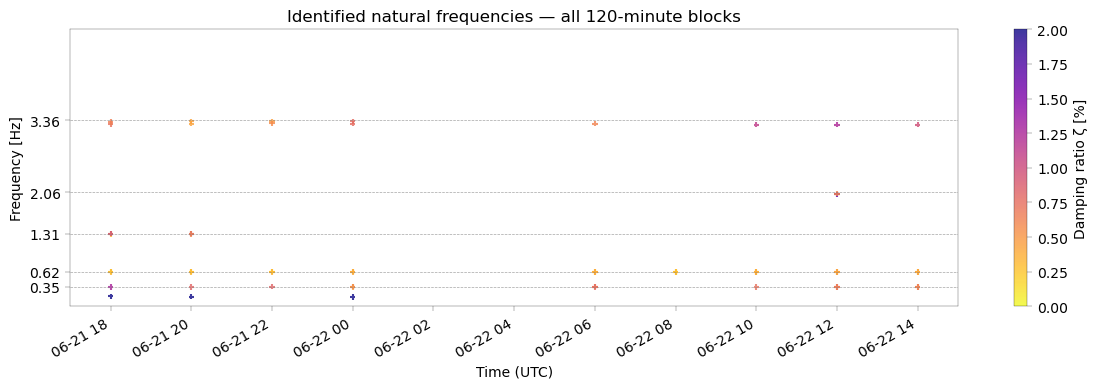

In [18]:
# Frequency scatter plot — all identified modes over time
fig, ax = plt.subplots(figsize=(12, 4))

all_times = modal.time.values
all_freqs = modal['frequencies'].values   # shape (time, modes)
all_damps = modal['damping'].values

# repeat times to match modes dimension
times_rep = np.repeat(all_times[:, np.newaxis], all_freqs.shape[1], axis=1)

sc = ax.scatter(times_rep.ravel(), all_freqs.ravel(),
                c=all_damps.ravel(), cmap='plasma_r',
                vmin=0, vmax=2, s=15, marker='+', alpha=0.8)
plt.colorbar(sc, ax=ax, label='Damping ratio ζ [%]')

# Reference frequencies from long-term analysis
ref_freqs = [0.35, 0.62, 1.31, 2.06, 3.36]
for f_ref in ref_freqs:
    ax.axhline(f_ref, color='grey', lw=0.5, ls='--', alpha=0.7)

ax.set_ylim(0, 5)
ax.set_yticks(ref_freqs)
ax.set_ylabel('Frequency [Hz]')
ax.set_xlabel('Time (UTC)')
ax.set_title('Identified natural frequencies — all 120-minute blocks')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

INFO:pyOMA.core.PreProcessingTools:Loading results from  /home/womo1998/Projects/grkgeyer/tower_scratch_data/120-minutes/modal_accel/2026/06/2026_06-21_20-00_prep_data.npz


Found 9 prep_data files.  Loading: 2026_06-21_20-00_prep_data.npz


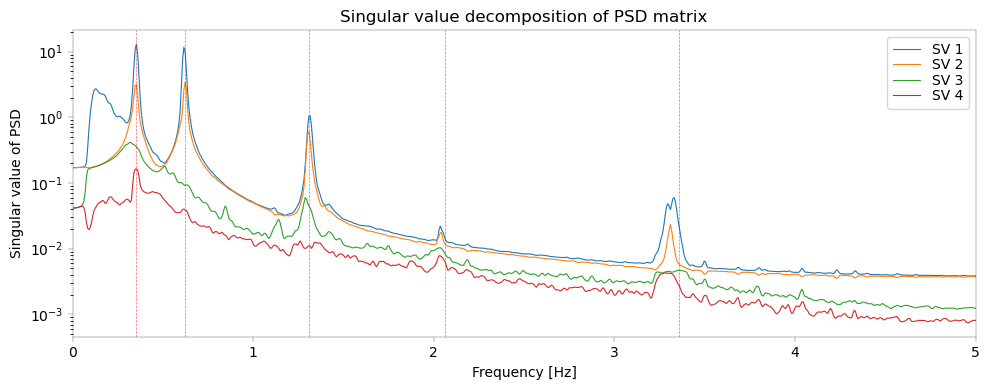

In [19]:
# Load a saved prep_data object to show the SVD-PSD (singular value spectrum)
from pyOMA.core.PreProcessingTools import PreProcessSignals

minutes = int(duration.total_seconds() / 60)
modal_folder = os.path.join(
    site.slice_root_path,
    f'{minutes}-minutes', 'modal_accel'
)

# Find the first available prep_data file
prep_files = []
for root, dirs, files in os.walk(modal_folder):
    for f in files:
        if f.endswith('_prep_data.npz'):
            prep_files.append(os.path.join(root, f))

if prep_files:
    prep_files.sort()
    print(f'Found {len(prep_files)} prep_data files.  Loading: {os.path.basename(prep_files[0])}')
    prep_data = PreProcessSignals.load_state(prep_files[0])
    s_vals_psd = prep_data.sv_psd(1444, method='blackman-tukey', refs_only=False)
    freqs      = prep_data.freqs

    fig, ax = plt.subplots(figsize=(10, 4))
    n_sv = min(s_vals_psd.shape[0], 4)
    for k in range(n_sv):
        ax.semilogy(freqs, np.abs(s_vals_psd[k, :]),
                    lw=0.8, label=f'SV {k+1}')
    for f_ref in ref_freqs:
        ax.axvline(f_ref, color='red', lw=0.5, ls='--', alpha=0.6)
    ax.set_xlim(0, 5)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Singular value of PSD')
    ax.set_title('Singular value decomposition of PSD matrix')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f'No prep_data files found in {modal_folder}.')
    print('Run the pipeline first: python daily.py -d 120 -q accel --modal')

---
## 5 — Post-processing visualisations

`post_processing.py` provides three main plotting functions:

| Function | Purpose |
|---|---|
| `plot_daily()` | Mean / min / max time-history per channel; frequency scatter for vibration data |
| `plot_waterfall()` | Colour-map of the first singular value PSD over time (frequency waterfall) |
| `postprocess_modal_results()` | Multi-panel scatter-matrix relating identified modal parameters to environmental quantities |

Both `plot_daily` and `plot_waterfall` are the functions called by the daily cron job
via `daily.py --plot` and the output figures are emailed to the supervisors.

In [20]:
from post_processing import plot_daily, plot_waterfall

# Use the earliest timestamp in the stats database as dtstart
dtstart = stats.time.values[0]   # UTC-naive np.datetime64
print(f'Plotting from: {pd.Timestamp(dtstart, tz="UTC")}')

Plotting from: 2026-06-21 12:00:00+00:00


### 5a — `plot_daily()`: time-history overview

INFO:monitoring:Getting statistics for wind (cached)


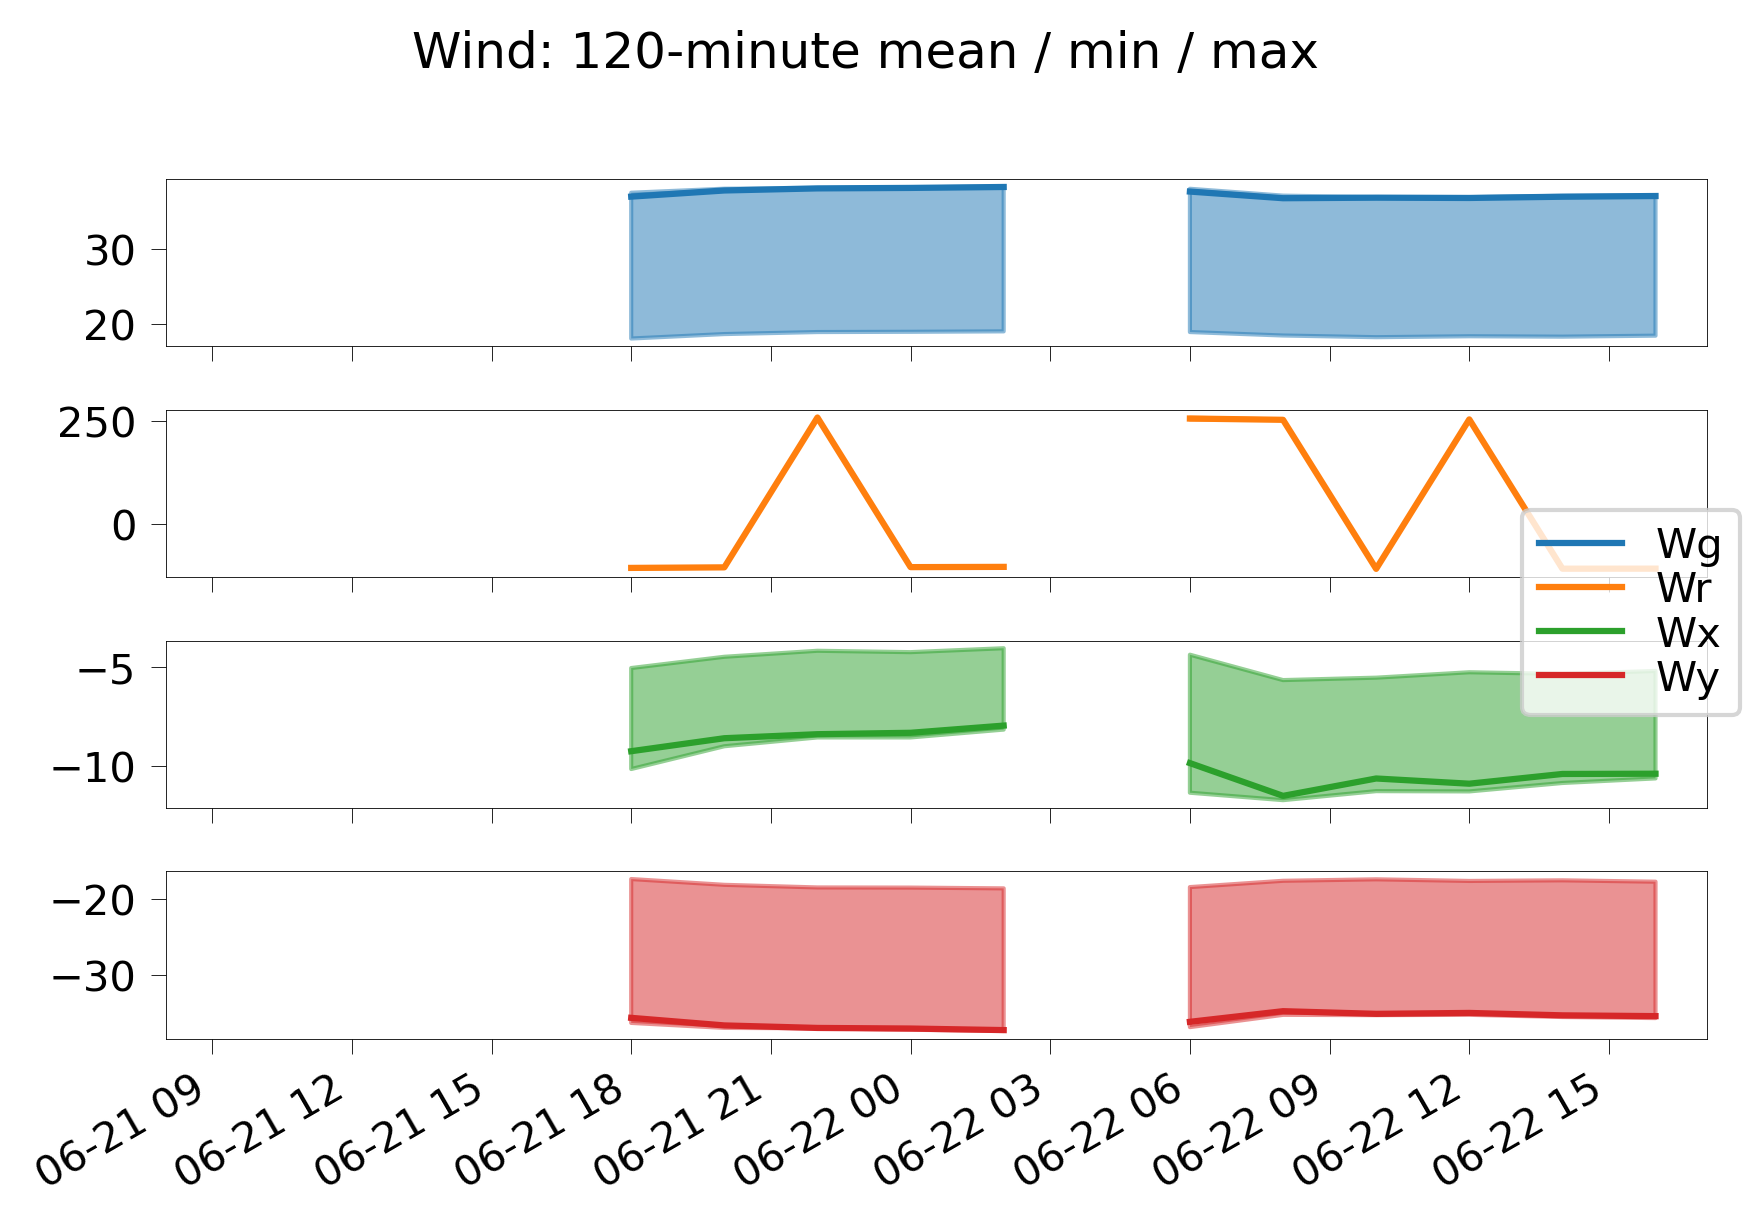

In [21]:
# plot_daily() for a non-modal quantity (wind)
fig_wind, _ = plot_daily('wind', duration, dtstart)
fig_wind.suptitle('Wind: 120-minute mean / min / max', y=1.01)
plt.show()

INFO:monitoring:Getting modal results for accel (cached)


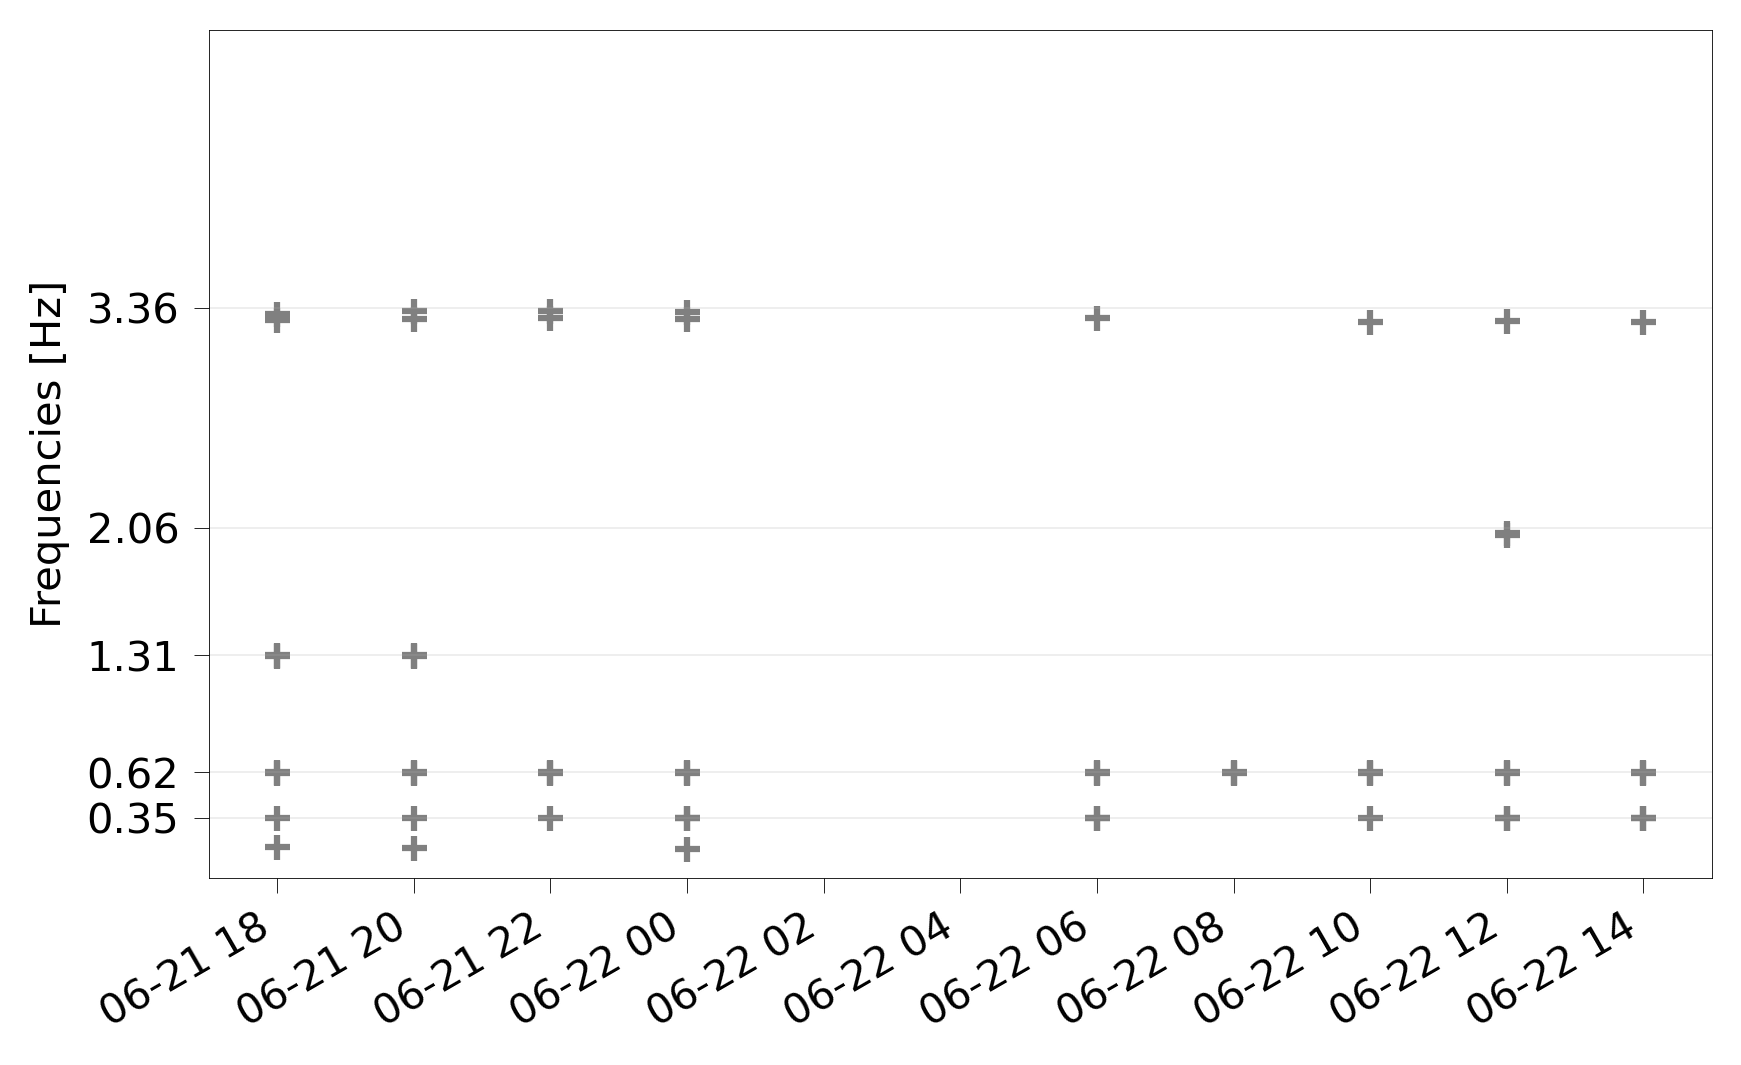

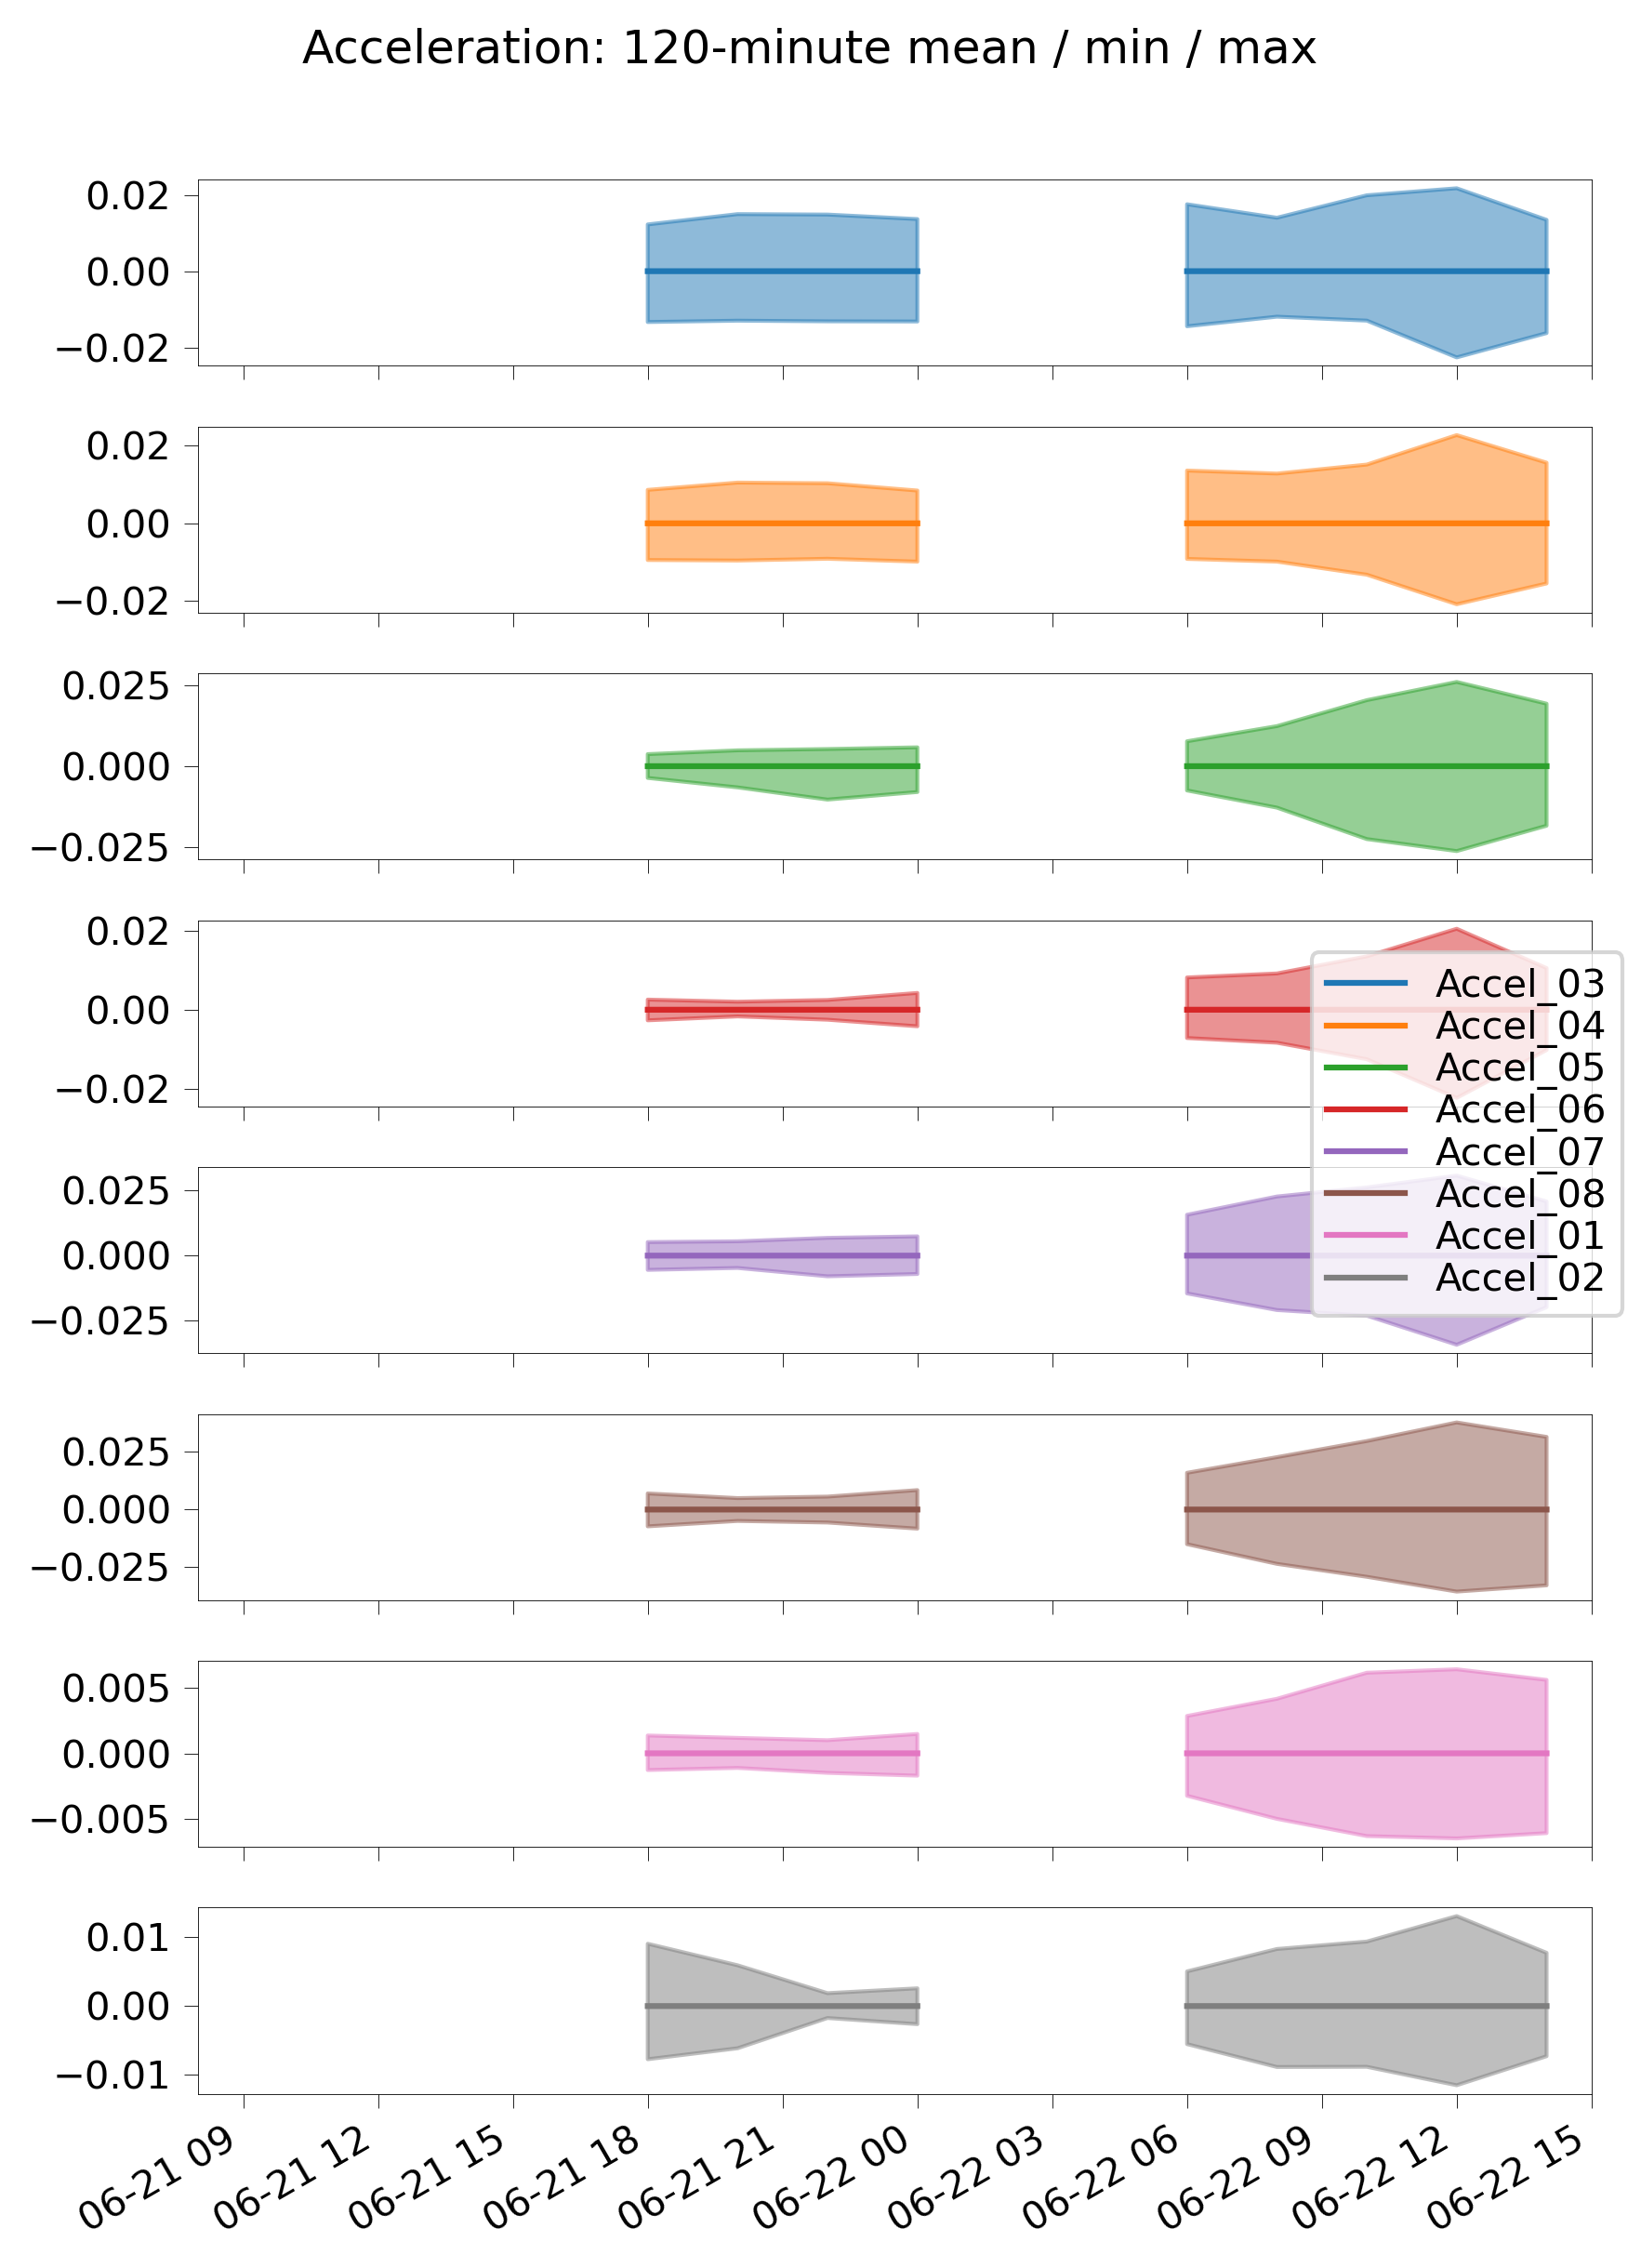

<Figure size 850.394x525.572 with 0 Axes>

In [22]:
# plot_daily() for accelerometers — returns two figures:
#   fig1 = per-channel mean / min / max
#   fig2 = frequency scatter (if modal results are present)
fig1, fig2 = plot_daily('accel', duration, dtstart)

fig1.suptitle('Acceleration: 120-minute mean / min / max', y=1.01)
plt.figure(fig1.number)
plt.show()

if fig2 is not None:
    fig2.suptitle('Identified natural frequencies — scatter over time', y=1.01)
    plt.figure(fig2.number)
    plt.show()
else:
    print('No modal results yet — run the modal pipeline to populate modal_accel.nc')

### 5b — `plot_waterfall()`: frequency waterfall diagram

INFO:monitoring:Getting modal results for accel (cached)
INFO:pyOMA.core.PreProcessingTools:Loading results from  /home/womo1998/Projects/grkgeyer/tower_scratch_data/120-minutes/modal_accel/2026/06/2026_06-21_20-00_prep_data.npz
INFO:pyOMA.core.PreProcessingTools:Estimating Power Spectral Density by Blackman-Tukey's method...
INFO:pyOMA.core.PreProcessingTools:Estimating Correlation Functions (BT) with m_lags=723 and n_segments=1...


....................................................................................................
....................................................................................................


INFO:pyOMA.core.PreProcessingTools:Loading results from  /home/womo1998/Projects/grkgeyer/tower_scratch_data/120-minutes/modal_accel/2026/06/2026_06-21_22-00_prep_data.npz
INFO:pyOMA.core.PreProcessingTools:Estimating Power Spectral Density by Blackman-Tukey's method...
INFO:pyOMA.core.PreProcessingTools:Estimating Correlation Functions (BT) with m_lags=723 and n_segments=1...


....................................................................................................
....................................................................................................


INFO:pyOMA.core.PreProcessingTools:Loading results from  /home/womo1998/Projects/grkgeyer/tower_scratch_data/120-minutes/modal_accel/2026/06/2026_06-22_00-00_prep_data.npz
INFO:pyOMA.core.PreProcessingTools:Estimating Power Spectral Density by Blackman-Tukey's method...
INFO:pyOMA.core.PreProcessingTools:Estimating Correlation Functions (BT) with m_lags=723 and n_segments=1...


...

....................................................................................................
....................................................................................................


INFO:pyOMA.core.PreProcessingTools:Loading results from  /home/womo1998/Projects/grkgeyer/tower_scratch_data/120-minutes/modal_accel/2026/06/2026_06-22_12-00_prep_data.npz
INFO:pyOMA.core.PreProcessingTools:Estimating Power Spectral Density by Blackman-Tukey's method...
INFO:pyOMA.core.PreProcessingTools:Estimating Correlation Functions (BT) with m_lags=723 and n_segments=1...


....................................................................................................
....................................................................................................


INFO:pyOMA.core.PreProcessingTools:Loading results from  /home/womo1998/Projects/grkgeyer/tower_scratch_data/120-minutes/modal_accel/2026/06/2026_06-22_14-00_prep_data.npz
INFO:pyOMA.core.PreProcessingTools:Estimating Power Spectral Density by Blackman-Tukey's method...
INFO:pyOMA.core.PreProcessingTools:Estimating Correlation Functions (BT) with m_lags=723 and n_segments=1...


....................................................................................................
....................................................................................................


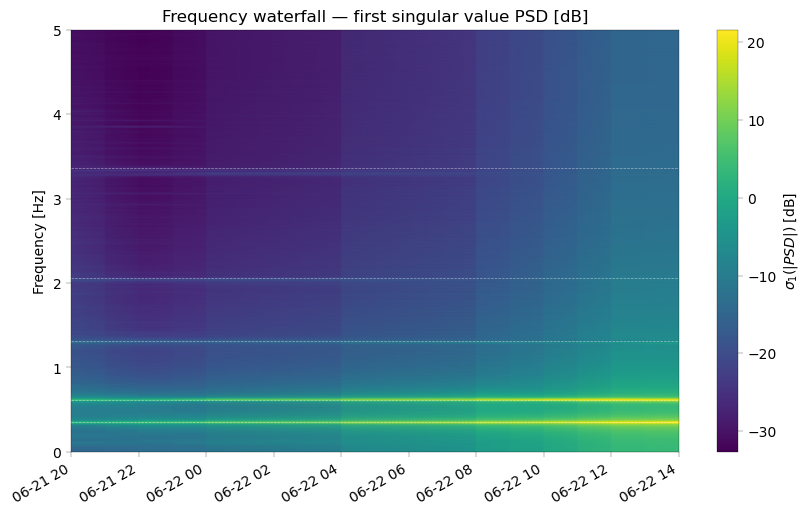

In [23]:
# The waterfall reads the saved prep_data .npz files directly
fig_wf = plot_waterfall('accel', duration, dtstart)

if fig_wf.get_axes():
    ax_wf = fig_wf.get_axes()[0]
    ax_wf.set_ylim(0, 5)
    ax_wf.set_title('Frequency waterfall — first singular value PSD [dB]')
    for f_ref in ref_freqs:
        ax_wf.axhline(f_ref, color='white', lw=0.5, ls='--', alpha=0.5)
plt.show()

### 5c — `plot_stats()` and `plot_file_info()`: exploratory diagnostic plots

These two functions are **interactive** — they respond to `pick_event` and let you
click on a data point to open the raw time series for that file or block.  They are
intended for use in a regular IPython/Qt session, not in a static notebook.  The cells
below show the non-interactive version.

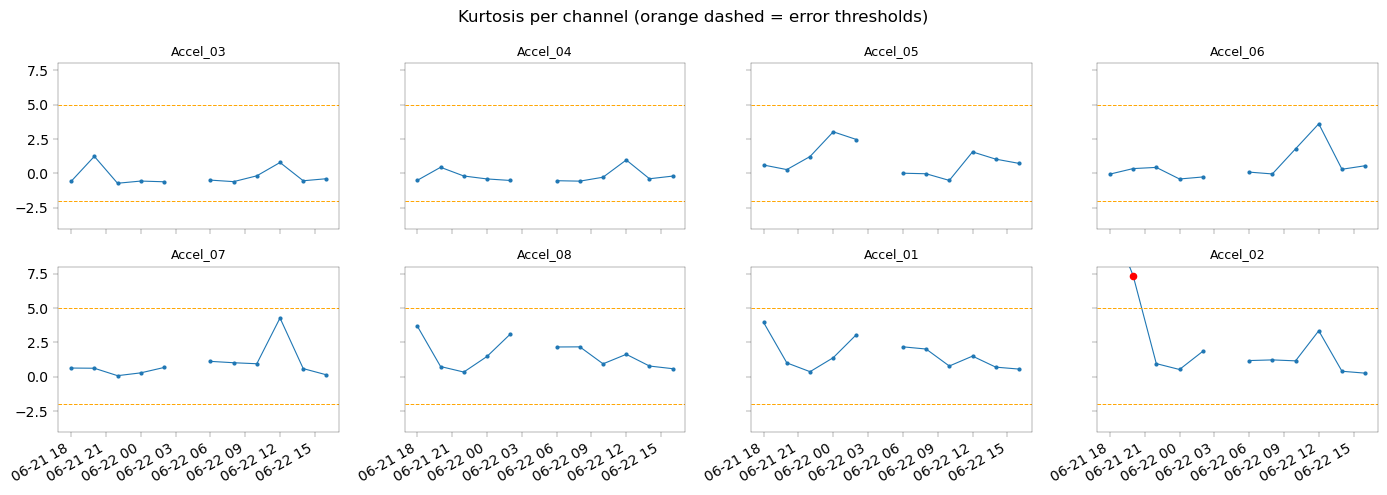

In [24]:
# Manual reproduction of plot_stats style: kurtosis per channel over time
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(14, 5), sharex=True, sharey=True)
axes = axes.flatten()

times_plot = pd.DatetimeIndex(stats.time.values, tz='UTC')
err_all = stats['error']

for i, ch in enumerate(stats.channels.values):
    kurt = stats['kurtosis'].sel(channels=ch).values
    err  = err_all.sel(channels=ch).values.astype(bool)
    axes[i].plot(times_plot, kurt, marker='.', ms=4, lw=0.8, color='C0', label='kurtosis')
    axes[i].scatter(times_plot[err], kurt[err], color='red', zorder=5, s=20, label='error')
    axes[i].axhline(5,  color='orange', lw=0.7, ls='--', label='thresh +5')
    axes[i].axhline(-2, color='orange', lw=0.7, ls='--', label='thresh -2')
    axes[i].set_title(str(ch), fontsize=9)

axes[0].set_ylim(-4, 8)
fig.suptitle('Kurtosis per channel (orange dashed = error thresholds)')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

### 5d — `postprocess_modal_results()`: multi-panel analysis

This function produces a **scatter-matrix** relating identified modal parameters
(frequency, damping) to environmental quantities (wind speed, temperature, RMS) and
to each other.  Upper-triangle panels show Spearman correlation coefficients; diagonal
panels show histograms.

It is most informative with multi-month datasets.  The cell below shows the function
call pattern; with only a few blocks of data the result will be sparse.

In [26]:
from post_processing import postprocess_modal_results

# Select the second mode pair (≈0.62 Hz — first visible in the data)
time_range = (
    pd.Timestamp(stats.time.values[0], tz='UTC').tz_convert('Europe/Berlin'),
    pd.Timestamp(stats.time.values[-1], tz='UTC').tz_convert('Europe/Berlin'),
)

fig_scatter = plt.figure(figsize=(9, 9), tight_layout=True)
ax_scatter  = plt.subplot(1, 1, 1)

postprocess_modal_results(
    'accel', duration,
    time_range=time_range,
    mode_pair=2,           # third named mode: ≈1.31 Hz
    q_1=['rms_m', 'wind', 'frequencies', 'damping'],
    q_2=['time', 'temp', 'wind', 'frequencies', 'damping'],
    color='steelblue',
    scatter=True,
    fig=fig_scatter, axes=ax_scatter,
)
plt.show()

INFO:monitoring:Getting modal results for accel (cached)
INFO:monitoring:Getting statistics for wind (cached)
INFO:monitoring:Getting statistics for temp (cached)


TypeError: object of type 'NoneType' has no len()

---
## Summary

This notebook walked through every stage of the `pyoma-monitoring` pipeline:

| Step | Function(s) | Output |
|---|---|---|
| 1. Read raw files | `read_file()` | numpy array + metadata |
| 2. Build file index | `create_file_info()` / `get_file_info()` | `file_info_<qty>.nc` |
| 2a. Time sync | `get_synchronized_time()`, `close_to_utc_transition()` | UTC-naive `time` coordinate |
| 3. Signal statistics | `create_stats()` / `get_stats()` → `describe_stats()` | `stats_<qty>.nc` |
| 4. Modal analysis | `create_modal_results()` → VarSSIRef + StabilCluster | `modal_<qty>.nc` |
| 5. Visualisation | `plot_daily()`, `plot_waterfall()`, `postprocess_modal_results()` | PNG figures |

The daily cron job (`daily2.sh` → `daily.py`) automates steps 1–5 for all four
quantities (`accel`, `wind`, `temp`, `strain_rosettes`) and emails the resulting
figures.

### Running the pipeline manually

```bash
# Full pipeline for the last 120 minutes, accelerometers
python daily.py -d 120 -q accel --file_info --stats --modal --plot --tmp_dir=/tmp

# Re-run stats for a specific start date (skips OMA)
python daily.py -d 120 -q wind --stats --dtstart='2024-06-01 00:00'

# Higher verbosity
python daily.py -d 120 -q accel --stats --modal --loglevel=INFO
```